# Running the FlyWire Drosophila SONATA Circuit with PyTorch

This notebook demonstrates how to:
1. Load a SONATA circuit converted from the FlyWire v783 Drosophila connectome
2. Build a PyTorch spiking neural network model (AlphaLIF)
3. Run the simulation on CPU or GPU
4. Visualize spike raster plots and firing rate distributions

The PyTorch model implements LIF neurons with alpha-function synapses, matching
the dynamics from the fly-brain benchmark suite (Shiu et al.).

**Prerequisites:**
- Run `convert_to_sonata.py` first to generate the SONATA circuit files
- `torch` and `h5py` Python packages installed

```bash
python convert_to_sonata.py --data-dir ../../fly-brain/data --output-dir ./sonata_circuit
```

In [1]:
import json
from pathlib import Path
from time import perf_counter

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

CIRCUIT_DIR = Path("./sonata_circuit")
assert CIRCUIT_DIR.exists(), (
    f"SONATA circuit not found at {CIRCUIT_DIR}. "
    "Run convert_to_sonata.py first."
)

# MPS does not support sparse CSR tensors, so only use CUDA or CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


## 1. Load SONATA Circuit Data

Read the SONATA HDF5 files to extract neuron count, synaptic connectivity, and experiment configuration.

In [2]:
def load_sonata_circuit(circuit_dir: Path) -> dict:
    """Load all SONATA circuit data from HDF5 files into a dict."""
    net = circuit_dir / "network"
    data = {}

    # -- Load configs --
    with open(circuit_dir / "circuit_config.json") as f:
        data["circuit_config"] = json.load(f)
    with open(circuit_dir / "simulation_config.json") as f:
        data["sim_config"] = json.load(f)
    with open(circuit_dir / "node_sets.json") as f:
        data["node_sets"] = json.load(f)

    # -- Internal nodes --
    with h5py.File(net / "internal_nodes.h5", "r") as f:
        pop = f["nodes/internal"]
        data["n_neurons"] = len(pop["node_id"])
        data["flywire_ids"] = pop["0/flywire_id"][:]

    # -- Internal edges --
    with h5py.File(net / "internal_internal_edges.h5", "r") as f:
        pop = f["edges/internal_to_internal"]
        data["pre_idx"] = pop["source_node_id"][:].astype(np.int64)
        data["post_idx"] = pop["target_node_id"][:].astype(np.int64)
        data["weights"] = pop["0/syn_weight"][:]
        data["delays"] = pop["0/delay"][:]

    # -- External edges (Poisson input targets) --
    with h5py.File(net / "external_internal_edges.h5", "r") as f:
        pop = f["edges/external_to_internal"]
        data["stim_targets"] = pop["target_node_id"][:].astype(np.int64)
        data["stim_weights"] = pop["0/syn_weight"][:]
        data["stim_delays"] = pop["0/delay"][:]

    # -- Neuron dynamics params --
    params_path = circuit_dir / "components" / "cell_models" / "flywire_lif.json"
    with open(params_path) as f:
        data["neuron_params"] = json.load(f)

    # -- Simulation parameters --
    data["duration_ms"] = data["sim_config"]["run"]["tstop"]
    data["dt"] = data["sim_config"]["run"]["dt"]

    return data


t0 = perf_counter()
circuit = load_sonata_circuit(CIRCUIT_DIR)
print(f"Loaded in {perf_counter() - t0:.1f}s")
print(f"  Neurons:           {circuit['n_neurons']:,}")
print(f"  Synaptic edges:    {len(circuit['weights']):,}")
print(f"  Stimulated neurons: {len(circuit['stim_targets'])}")
print(f"  Simulation:        {circuit['duration_ms']} ms at dt={circuit['dt']} ms")

Loaded in 0.1s
  Neurons:           138,639
  Synaptic edges:    15,091,983
  Stimulated neurons: 2
  Simulation:        5000.0 ms at dt=0.1 ms


## 2. PyTorch AlphaLIF Model

Model architecture (from Shiu et al.):

    PoissonSpikeGenerator → recurrent weights (sparse matmul) → AlphaLIF

where AlphaLIF = AlphaSynapse + LIFNeuron + refractory period.

The SONATA weights already include the `wScale` (0.275) factor from the original model,
so we set `wScale=1.0` here. Similarly, the Poisson scale is set to the SONATA `stim_weight` (68.75)
to match the original `wScale * scalePoisson = 0.275 * 250`.

In [3]:
class PoissonSpikeGenerator(nn.Module):
    """Generates one timestep of Poisson-distributed spikes from firing rates."""

    def __init__(self, dt, scale, device="cpu"):
        super().__init__()
        self.prob_scale = dt / 1000.0
        self.scale = scale
        self.device = device

    def forward(self, rates):
        return torch.bernoulli(rates * self.prob_scale) * self.scale


class AlphaSynapse(nn.Module):
    """Alpha-function synapse dynamics with configurable delay."""

    def __init__(self, size, dt, tau_syn, delay_ms, device="cpu"):
        super().__init__()
        self.time_factor = dt / tau_syn
        self.steps_delay = int(delay_ms / dt)
        self.size = size
        self.device = device

    def state_init(self):
        conductance = torch.zeros(self.size, device=self.device)
        delay_buffer = torch.zeros(
            self.steps_delay + 1, self.size, device=self.device
        )
        return conductance, delay_buffer

    def forward(self, input_, conductance, delay_buffer, refrac):
        conductance_new = (
            conductance * (1 - self.time_factor) + delay_buffer[0, :] * refrac
        )
        delay_buffer = torch.roll(delay_buffer, shifts=-1, dims=0)
        delay_buffer[-1, :] = input_
        return conductance_new, delay_buffer


class LIFNeuron(nn.Module):
    """Leaky Integrate-and-Fire neuron with surrogate gradient (ATan)."""

    def __init__(self, size, dt, params, device="cpu"):
        super().__init__()
        self.size = size
        self.time_factor = dt / params["tauMem"]
        self.v_reset = params["vReset"]
        self.v_rest = params["vRest"]
        self.v_threshold = params["vThreshold"]
        self.v_0 = params["v0"]
        self.device = device

    def state_init(self):
        v = torch.zeros(self.size, device=self.device) + self.v_0
        spikes = torch.zeros(self.size, device=self.device)
        return spikes, v

    def forward(self, input_current, v):
        v = v + self.time_factor * (input_current - (v - self.v_rest))
        spike = (v > self.v_threshold).float()
        reset = ((v - self.v_reset) * spike).detach()
        v = v - reset
        return spike, v


class AlphaLIF(nn.Module):
    """LIF neuron with alpha-function synapse dynamics and refractory period."""

    def __init__(self, size, dt, params, device="cpu"):
        super().__init__()
        self.synapse = AlphaSynapse(
            size, dt, params["tauSyn"], params["tDelay"], device=device
        )
        self.neuron = LIFNeuron(size, dt, params, device=device)
        self.steps_refrac = int(params["tRefrac"] / dt)

    def state_init(self):
        conductance, delay_buffer = self.synapse.state_init()
        spikes, v = self.neuron.state_init()
        refrac = self.steps_refrac + torch.zeros_like(v)
        return conductance, delay_buffer, spikes, v, refrac

    def forward(self, input_, conductance, delay_buffer, spikes, v, refrac):
        refrac = refrac * (1 - spikes) + 1
        conductance_new, delay_buffer = self.synapse(
            input_, conductance, delay_buffer,
            (refrac > self.steps_refrac).float(),
        )
        spikes, v_new = self.neuron(conductance, v)
        conductance_reset = (conductance_new * spikes).detach()
        conductance_new = conductance_new - conductance_reset
        return conductance_new, delay_buffer, spikes, v_new, refrac


class SonataModel(nn.Module):
    """Top-level model: Poisson input + recurrent SONATA weights + AlphaLIF."""

    def __init__(self, size, dt, params, weights_sparse, device="cpu"):
        super().__init__()
        self.neurons = AlphaLIF(size, dt, params, device=device)
        self.weights = weights_sparse
        self.poisson = PoissonSpikeGenerator(
            dt, params["scalePoisson"], device=device
        )
        self.w_scale = params["wScale"]

    def state_init(self):
        return self.neurons.state_init()

    def forward(self, rates, conductance, delay_buffer, spikes, v, refrac):
        spikes_input = self.poisson(rates)
        weighted_spikes = torch.mv(self.weights, spikes)
        conductance, delay_buffer, spikes, v, refrac = self.neurons(
            self.w_scale * (spikes_input + weighted_spikes),
            conductance, delay_buffer, spikes, v, refrac,
        )
        return conductance, delay_buffer, spikes, v, refrac

## 3. Build Model from SONATA Circuit

Construct the sparse weight matrix from SONATA edge data and map neuron parameters.

In [4]:
t0 = perf_counter()

# -- Map SONATA neuron params to PyTorch model params --
np_ = circuit["neuron_params"]
dt = circuit["dt"]
stim_weight = float(circuit["stim_weights"][0])  # 68.75 = wScale * scalePoisson
stim_rate = circuit["sim_config"].get("metadata", {}).get("stim_rate_hz", 200.0)

params = {
    "tauSyn": np_["tau_syn_ex"],
    "tDelay": float(circuit["delays"][0]),
    "v0": np_["E_L"],
    "vReset": np_["V_reset"],
    "vRest": np_["E_L"],
    "vThreshold": np_["V_th"],
    "tauMem": np_["tau_m"],
    "tRefrac": np_["t_ref"],
    # SONATA weights already include wScale (0.275), so set wScale=1.0
    # and scalePoisson = stim_weight (= original wScale * scalePoisson = 68.75)
    "scalePoisson": stim_weight,
    "wScale": 1.0,
}

n = circuit["n_neurons"]
SIM_DURATION_MS = circuit["duration_ms"]
num_steps = int(SIM_DURATION_MS / dt)

# -- Build sparse weight matrix (post x pre, CSR) from SONATA edges --
print("Building sparse weight matrix...")
t1 = perf_counter()
weight_coo = torch.sparse_coo_tensor(
    torch.tensor([circuit["post_idx"], circuit["pre_idx"]], dtype=torch.long),
    torch.tensor(circuit["weights"], dtype=torch.float32),
    size=(n, n),
).coalesce()
weights_sparse = weight_coo.to_sparse_csr().to(DEVICE)
print(f"  Weight matrix: {n:,} x {n:,}, {len(circuit['weights']):,} nnz")
print(f"  Built in {perf_counter() - t1:.2f}s")

# -- Create model --
model = SonataModel(n, dt, params, weights_sparse, device=DEVICE)
conductance, delay_buffer, spikes, v, refrac = model.state_init()

# -- Setup Poisson input rates --
rates = torch.zeros(n, device=DEVICE)
rates[circuit["stim_targets"]] = stim_rate

print(f"\nModel ready on {DEVICE.upper()}")
print(f"  Neurons: {n:,}")
print(f"  Stimulated: {len(circuit['stim_targets'])} at {stim_rate} Hz")
print(f"  Simulation: {SIM_DURATION_MS} ms ({num_steps:,} steps at dt={dt} ms)")
print(f"  Setup time: {perf_counter() - t0:.2f}s")

Building sparse weight matrix...


/var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/ipykernel_27056/29942536.py:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  torch.tensor([circuit["post_idx"], circuit["pre_idx"]], dtype=torch.long),
/var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/ipykernel_27056/29942536.py:31: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  weight_coo = torch.sparse_coo_

  Weight matrix: 138,639 x 138,639, 15,091,983 nnz
  Built in 3.07s

Model ready on CPU
  Neurons: 138,639
  Stimulated: 2 at 100.0 Hz
  Simulation: 5000.0 ms (50,000 steps at dt=0.1 ms)
  Setup time: 3.08s


/var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/ipykernel_27056/29942536.py:36: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:51.)
  weights_sparse = weight_coo.to_sparse_csr().to(DEVICE)


## 4. Run Simulation

In [5]:
spike_neuron_idx = []
spike_timesteps = []

print(f"Simulating {SIM_DURATION_MS} ms ({num_steps:,} steps)...")
t_sim = perf_counter()

with torch.no_grad():
    for t_step in range(num_steps):
        conductance, delay_buffer, spikes, v, refrac = model(
            rates, conductance, delay_buffer, spikes, v, refrac
        )
        spike_mask = spikes > 0
        if spike_mask.any():
            n_idx = spike_mask.nonzero(as_tuple=True)[0]
            spike_neuron_idx.append(n_idx.cpu())
            spike_timesteps.append(
                torch.full((len(n_idx),), t_step, dtype=torch.long)
            )

        if num_steps >= 10000 and (t_step + 1) % (num_steps // 10) == 0:
            elapsed = perf_counter() - t_sim
            pct = (t_step + 1) / num_steps * 100
            print(f"  {pct:3.0f}% ({t_step+1:,}/{num_steps:,}) - {elapsed:.1f}s")

if DEVICE == "cuda":
    torch.cuda.synchronize()

sim_time = perf_counter() - t_sim

# Collect spike data
if spike_neuron_idx:
    all_neurons = torch.cat(spike_neuron_idx).numpy()
    all_timesteps = torch.cat(spike_timesteps).numpy()
    spike_times = all_timesteps * dt
    spike_ids = all_neurons
else:
    spike_times = np.array([])
    spike_ids = np.array([], dtype=np.int64)

# Build per-neuron spike trains
spike_trains = [[] for _ in range(n)]
for t_ms, nidx in zip(spike_times, spike_ids):
    spike_trains[nidx].append(t_ms)
spike_trains = [np.array(s) for s in spike_trains]

n_total_spikes = len(spike_times)
n_active = sum(1 for t in spike_trains if len(t) > 0)

print(f"\nSimulation: {sim_time:.2f}s  (realtime ratio: {SIM_DURATION_MS / 1000 / sim_time:.3f}x)")
print(f"  Total spikes:   {n_total_spikes:,}")
print(f"  Active neurons: {n_active:,} / {n:,} ({100 * n_active / n:.1f}%)")

Simulating 5000.0 ms (50,000 steps)...
   10% (5,000/50,000) - 14.6s
   20% (10,000/50,000) - 28.8s
   30% (15,000/50,000) - 43.8s
   40% (20,000/50,000) - 58.2s
   50% (25,000/50,000) - 72.9s
   60% (30,000/50,000) - 87.9s
   70% (35,000/50,000) - 103.1s
   80% (40,000/50,000) - 117.2s
   90% (45,000/50,000) - 131.3s
  100% (50,000/50,000) - 145.6s

Simulation: 145.57s  (realtime ratio: 0.034x)
  Total spikes:   2,151
  Active neurons: 126 / 138,639 (0.1%)


## 5. Save Results in SONATA Spikes Format

In [6]:
output_dir = CIRCUIT_DIR / "output"
output_dir.mkdir(exist_ok=True)
spikes_path = output_dir / "spikes_pytorch.h5"

sort_idx = np.argsort(spike_times)
sorted_times = spike_times[sort_idx]
sorted_ids = spike_ids[sort_idx]

with h5py.File(spikes_path, "w") as f:
    pop = f.create_group("spikes/internal")
    ds = pop.create_dataset("timestamps", data=sorted_times)
    ds.attrs["units"] = "ms"
    pop.create_dataset("node_ids", data=sorted_ids.astype(np.uint64))
    pop.attrs["sorting"] = "by_time"

print(f"Spikes saved to {spikes_path}")
print(f"  {len(sorted_times):,} spikes from {n_active:,} neurons")

Spikes saved to sonata_circuit/output/spikes_pytorch.h5
  2,151 spikes from 126 neurons


## 6. Visualize Results

### 6a. Spike Raster Plot

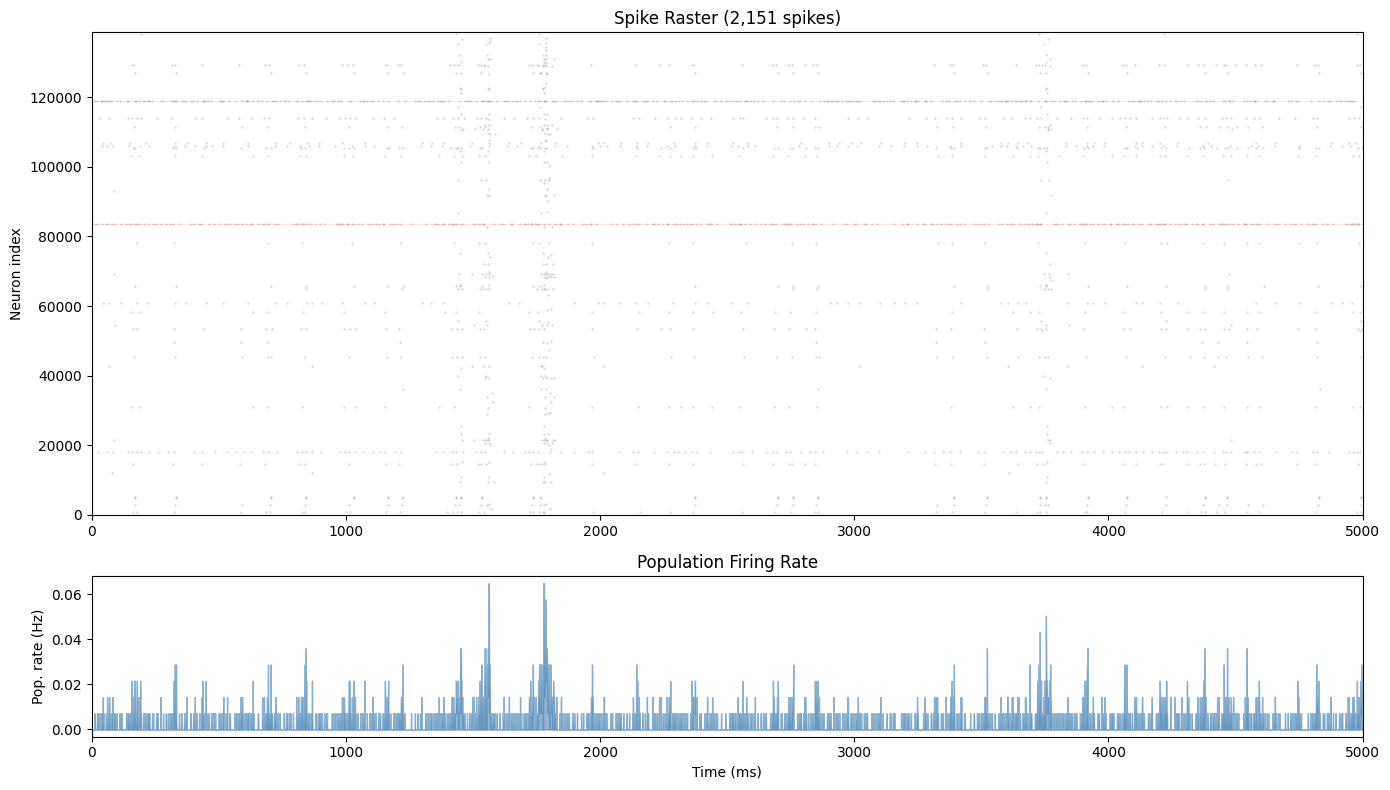

Saved to sonata_circuit/output/raster_plot_pytorch.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})

# Raster plot (subsample for readability)
ax = axes[0]
max_points = 200_000
if len(spike_times) > max_points:
    idx = np.random.default_rng(0).choice(len(spike_times), max_points, replace=False)
    ax.scatter(spike_times[idx], spike_ids[idx], s=0.1, alpha=0.3, c="k", rasterized=True)
    ax.set_title(f"Spike Raster ({max_points:,} of {len(spike_times):,} spikes shown)")
else:
    ax.scatter(spike_times, spike_ids, s=0.1, alpha=0.3, c="k", rasterized=True)
    ax.set_title(f"Spike Raster ({len(spike_times):,} spikes)")

for stim_idx in circuit["stim_targets"]:
    ax.axhline(y=stim_idx, color="red", alpha=0.15, linewidth=0.5)

ax.set_ylabel("Neuron index")
ax.set_xlim(0, SIM_DURATION_MS)
ax.set_ylim(-0.5, n)

# Population firing rate histogram (1 ms bins)
ax2 = axes[1]
bin_width = 1.0
bins = np.arange(0, SIM_DURATION_MS + bin_width, bin_width)
counts, _ = np.histogram(spike_times, bins=bins)
rate_hz = counts / (bin_width / 1000) / n
ax2.fill_between(bins[:-1], rate_hz, alpha=0.6, color="steelblue")
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Pop. rate (Hz)")
ax2.set_xlim(0, SIM_DURATION_MS)
ax2.set_title("Population Firing Rate")

plt.tight_layout()
plt.savefig(output_dir / "raster_plot_pytorch.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {output_dir / 'raster_plot_pytorch.png'}")

### 6b. Per-Neuron Firing Rate Distribution

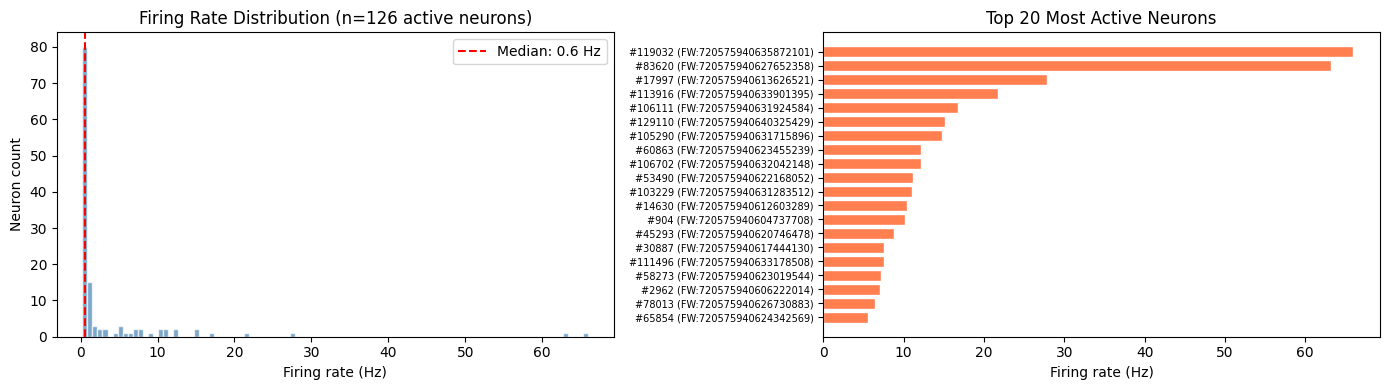


Firing rate stats (active neurons):
  Mean:   3.41 Hz
  Median: 0.60 Hz
  Max:    66.00 Hz
  Std:    8.98 Hz


In [8]:
duration_s = SIM_DURATION_MS / 1000.0
spike_counts = np.array([len(t) for t in spike_trains])
firing_rates = spike_counts / duration_s

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

active_rates = firing_rates[firing_rates > 0]
ax = axes[0]
ax.hist(active_rates, bins=100, color="steelblue", alpha=0.7, edgecolor="white")
ax.set_xlabel("Firing rate (Hz)")
ax.set_ylabel("Neuron count")
ax.set_title(f"Firing Rate Distribution (n={len(active_rates):,} active neurons)")
ax.axvline(np.median(active_rates), color="red", linestyle="--",
           label=f"Median: {np.median(active_rates):.1f} Hz")
ax.legend()

ax2 = axes[1]
top_k = 20
top_idx = np.argsort(firing_rates)[-top_k:][::-1]
top_rates = firing_rates[top_idx]
top_flywire = circuit["flywire_ids"][top_idx]

ax2.barh(range(top_k), top_rates, color="coral", edgecolor="white")
ax2.set_yticks(range(top_k))
ax2.set_yticklabels([f"#{i} (FW:{fid})" for i, fid in zip(top_idx, top_flywire)],
                     fontsize=7)
ax2.set_xlabel("Firing rate (Hz)")
ax2.set_title(f"Top {top_k} Most Active Neurons")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(output_dir / "firing_rates_pytorch.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFiring rate stats (active neurons):")
print(f"  Mean:   {np.mean(active_rates):.2f} Hz")
print(f"  Median: {np.median(active_rates):.2f} Hz")
print(f"  Max:    {np.max(active_rates):.2f} Hz")
print(f"  Std:    {np.std(active_rates):.2f} Hz")